# P35: Medical Insurance Cost Estimator

**Problem:** Give transparency on expected healthcare insurance costs based on personal factors (age, sex, BMI, smoker status, region, and number of children).

**Dataset:** [Medical Cost Personal Datasets — Kaggle](https://www.kaggle.com/datasets/mirichoi0218/insurance) — 1,338 records.

**Approach:** Three regression models are trained and compared on the same train/test split — Linear Regression, Polynomial Regression (degree 2), and a tuned Random Forest Regressor — using RMSE and R² as the evaluation metrics, with residual plots to check whether errors grow for certain age groups.

**Stretch goal:** quantify exactly how much being a smoker adds to predicted insurance cost.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Custom brown theme used across every chart in this notebook
BROWN_PALETTE = ["#D9B18E", "#A67564", "#723E31", "#3E1F14"]
BROWN_EDGE = "#3E1F14"
BROWN_CMAP = LinearSegmentedColormap.from_list(
    "browns", ["#F5E6D3", "#D9B18E", "#A67564", "#723E31", "#3E1F14"]
)

df = pd.read_csv("/kaggle/input/datasets/mirichoi0218/insurance/insurance.csv")

In [2]:
print("="*50)
print("SHAPE OF DATASET")
print("="*50)
print(f"Shape of dataset is: {df.shape}")

print("\n" + "="*50)
print("FIRST 5 ROWS")
print("="*50)
print(df.head())

print("\n" + "="*50)
print("Columns Name")
print("="*50)
print(df.columns)

print("\n" + "="*50)
print("DATA TYPES")
print("="*50)
print(df.dtypes)

print("\n" + "="*50)
print("MISSING VALUES")
print("="*50)
print(df.isnull().sum())

print("\n" + "="*50)
print("STATISTICAL SUMMARY")
print("="*50)
print(df.describe())

print("\n" + "="*50)
print("DUPLICATE ROWS")
print("="*50)
print(f"Number of duplicate rows: {df.duplicated().sum()}")

SHAPE OF DATASET
Shape of dataset is: (1338, 7)

FIRST 5 ROWS
   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520

Columns Name
Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

DATA TYPES
age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

MISSING VALUES
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

STATISTICAL SUMMARY
               age          bmi     children       charges
count  1338.000000  1338.000000  1338.000000   1338.000000
mean     39.207025  

In [3]:
df = df.drop_duplicates()
print(df.shape)

(1337, 7)


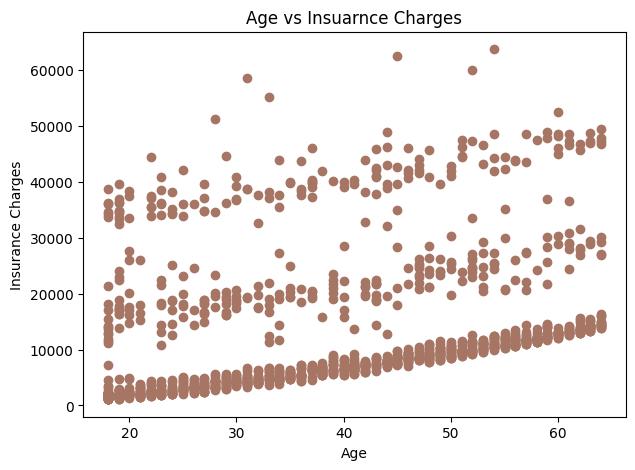

In [4]:
plt.figure(figsize=(7,5))
plt.scatter(df['age'],df['charges'],color='#A67564')
plt.xlabel("Age")
plt.ylabel("Insurance Charges")
plt.title("Age vs Insuarnce Charges")
plt.show()

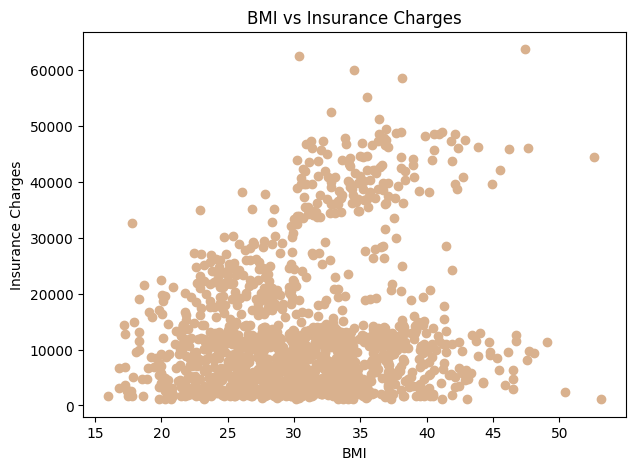

In [5]:
plt.figure(figsize=(7,5))
plt.scatter(df["bmi"], df["charges"],color=['#D9B18E'])
plt.xlabel("BMI")
plt.ylabel("Insurance Charges")
plt.title("BMI vs Insurance Charges")
plt.show()

<Figure size 700x500 with 0 Axes>

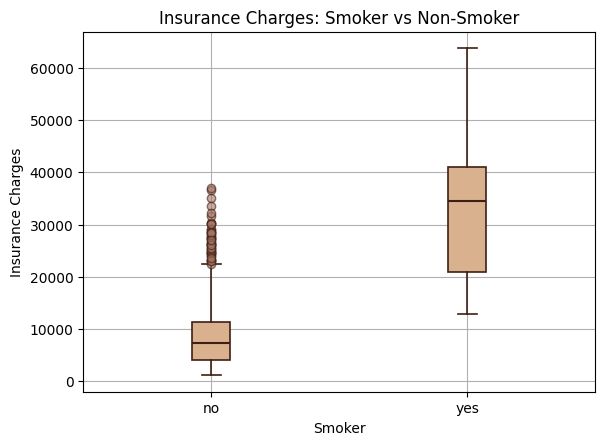

In [6]:
plt.figure(figsize=(7,5))
box = df.boxplot(
    column="charges", by="smoker", patch_artist=True,
    boxprops=dict(facecolor='#D9B18E', color=BROWN_EDGE, linewidth=1.2),
    medianprops=dict(color=BROWN_EDGE, linewidth=1.5),
    whiskerprops=dict(color=BROWN_EDGE, linewidth=1.2),
    capprops=dict(color=BROWN_EDGE, linewidth=1.2),
    flierprops=dict(markerfacecolor='#A67564', markeredgecolor=BROWN_EDGE, marker='o', alpha=0.6)
)
plt.title("Insurance Charges: Smoker vs Non-Smoker")
plt.suptitle("")
plt.xlabel("Smoker")
plt.ylabel("Insurance Charges")
plt.show()

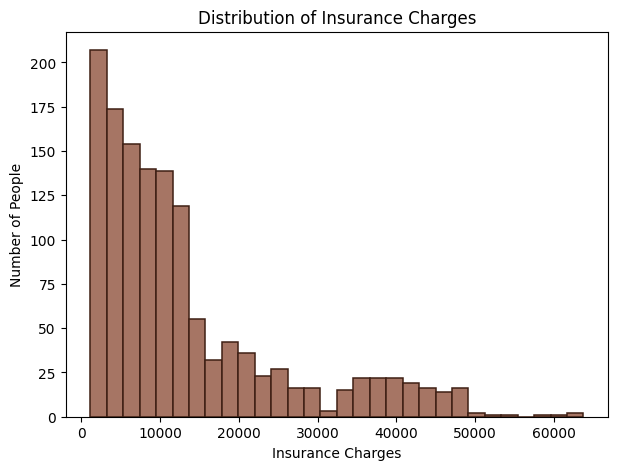

In [7]:
plt.figure(figsize=(7,5))
plt.hist(df["charges"], bins=30, color='#A67564', edgecolor=BROWN_EDGE, linewidth=1.1)
plt.xlabel("Insurance Charges")
plt.ylabel("Number of People")
plt.title("Distribution of Insurance Charges")
plt.show()

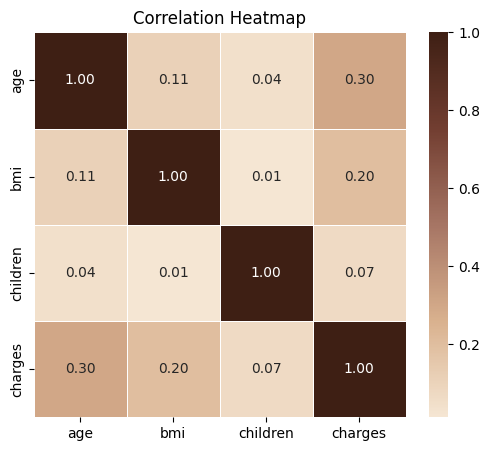

In [8]:
plt.figure(figsize=(6,5))
corr = df[['age','bmi','children','charges']].corr()
sns.heatmap(corr, annot=True, cmap=BROWN_CMAP, fmt='.2f', linewidths=0.5, linecolor='white')
plt.title("Correlation Heatmap")
plt.show()

In [9]:
df["sex"] = df["sex"].map({ "male": 1,"female": 0})


In [10]:
df["smoker"] = df["smoker"].map({"yes": 1,"no": 0})

In [11]:
df = pd.get_dummies(df, columns=["region"], drop_first=True)

In [12]:
df.head()

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,16884.92400,False,False,True
1,18,1,33.770,1,0,1725.55230,False,True,False
2,28,1,33.000,3,0,4449.46200,False,True,False
3,33,1,22.705,0,0,21984.47061,True,False,False
4,32,1,28.880,0,0,3866.85520,True,False,False


In [13]:
X = df.drop("charges", axis=1)
y = df["charges"]
print("="*50)
print("SHAPE OF FEATURES AND TARGET")
print("="*50)
print(f"Shape of X (Features): {X.shape}")
print(f"Shape of y (Target): {y.shape}")

SHAPE OF FEATURES AND TARGET
Shape of X (Features): (1337, 8)
Shape of y (Target): (1337,)


In [14]:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [15]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (1069, 8)
X_test: (268, 8)
y_train: (1069,)
y_test: (268,)


In [16]:
linear_model=LinearRegression()
linear_model.fit(X_train,y_train)
y_pred_linear=linear_model.predict(X_test)

print("="*50)
print("LINEAR REGRESSION PREDICTIONS")
print("="*50)

print("Actual Charges:", y_test.head().values)
print("Predicted Charges:", y_pred_linear[:5])

rmse_linear = np.sqrt(mean_squared_error(y_test, y_pred_linear))

r2_linear = r2_score(y_test, y_pred_linear)

print()
print("="*50)
print("LINEAR REGRESSION EVALUATION")
print("="*50)

print(f"RMSE: ${rmse_linear:.2f}")
print(f"R² Score: {r2_linear:.4f}")

LINEAR REGRESSION PREDICTIONS
Actual Charges: [ 8688.85885  5708.867   11436.73815 38746.3551   4463.2051 ]
Predicted Charges: [ 8143.69388412  5737.11568259 14369.31487618 31745.51363586
  8962.38665706]

LINEAR REGRESSION EVALUATION
RMSE: $5956.34
R² Score: 0.8069


In [17]:

polynomial_model = make_pipeline( PolynomialFeatures(degree=2),LinearRegression() )

polynomial_model.fit(X_train, y_train)

y_pred_polynomial = polynomial_model.predict(X_test)

print("="*50)
print("POLYNOMIAL REGRESSION PREDICTIONS")
print("="*50)

print("Actual Charges:", y_test.head().values)
print("Predicted Charges:", y_pred_polynomial[:5])


rmse_polynomial = np.sqrt(
    mean_squared_error(y_test, y_pred_polynomial)
)

r2_polynomial = r2_score(y_test, y_pred_polynomial)

print()
print("="*50)
print("POLYNOMIAL REGRESSION EVALUATION")
print("="*50)

print(f"RMSE: ${rmse_polynomial:.2f}")
print(f"R² Score: {r2_polynomial:.4f}")

POLYNOMIAL REGRESSION PREDICTIONS
Actual Charges: [ 8688.85885  5708.867   11436.73815 38746.3551   4463.2051 ]
Predicted Charges: [ 8353.84308898  6542.11918975 14316.73674593 35908.93406513
  5652.79736389]

POLYNOMIAL REGRESSION EVALUATION
RMSE: $4646.06
R² Score: 0.8825


In [18]:


random_forest_model = RandomForestRegressor(n_estimators=600, max_depth=15,min_samples_split=26,min_samples_leaf=12,random_state=42)

random_forest_model.fit(X_train, y_train)


y_pred_random_forest = random_forest_model.predict(X_test)

print("="*50)
print("RANDOM FOREST REGRESSION PREDICTIONS")
print("="*50)

print("Actual Charges:", y_test.head().values)
print("Predicted Charges:", y_pred_random_forest[:5])

rmse_random_forest = np.sqrt(
    mean_squared_error(y_test, y_pred_random_forest)
)

r2_random_forest = r2_score(
    y_test, y_pred_random_forest
)

print()
print("="*50)
print("RANDOM FOREST REGRESSION EVALUATION")
print("="*50)

print(f"RMSE: ${rmse_random_forest:.2f}")
print(f"R² Score: {r2_random_forest:.4f}")

RANDOM FOREST REGRESSION PREDICTIONS
Actual Charges: [ 8688.85885  5708.867   11436.73815 38746.3551   4463.2051 ]
Predicted Charges: [10690.94585509  6243.40313643 12297.68691479 40173.4242347
  5500.30852811]

RANDOM FOREST REGRESSION EVALUATION
RMSE: $4282.68
R² Score: 0.9002


In [19]:
print("="*60)
print("REGRESSION MODEL COMPARISON")
print("="*60)

model_names = [
    "Linear Regression",
    "Polynomial Regression",
    "Random Forest Regression"
]

rmse_values = [
    rmse_linear,
    rmse_polynomial,
    rmse_random_forest
]

r2_values = [
    r2_linear,
    r2_polynomial,
    r2_random_forest
]

comparison = pd.DataFrame({
    "Model": model_names,
    "RMSE": rmse_values,
    "R² Score": r2_values
})

print(comparison)

REGRESSION MODEL COMPARISON
                      Model         RMSE  R² Score
0         Linear Regression  5956.342894  0.806929
1     Polynomial Regression  4646.056793  0.882530
2  Random Forest Regression  4282.682317  0.900186


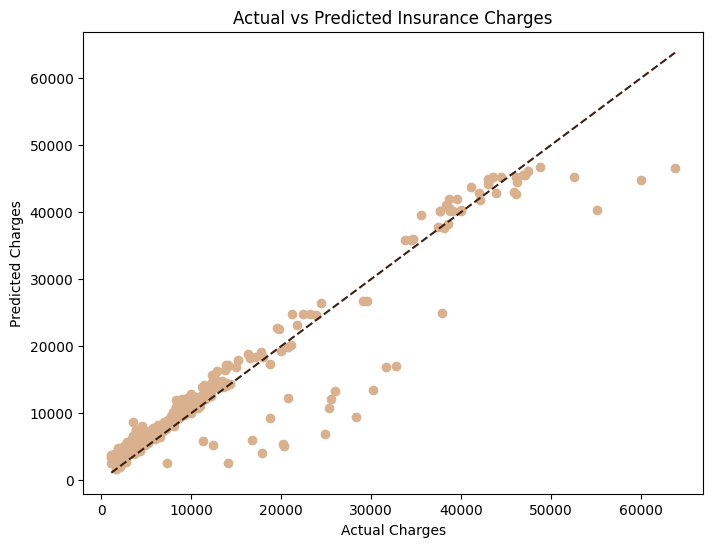

In [20]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred_random_forest,color=['#D9B18E'])

plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted Insurance Charges")

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--",color=BROWN_EDGE
)

plt.show()

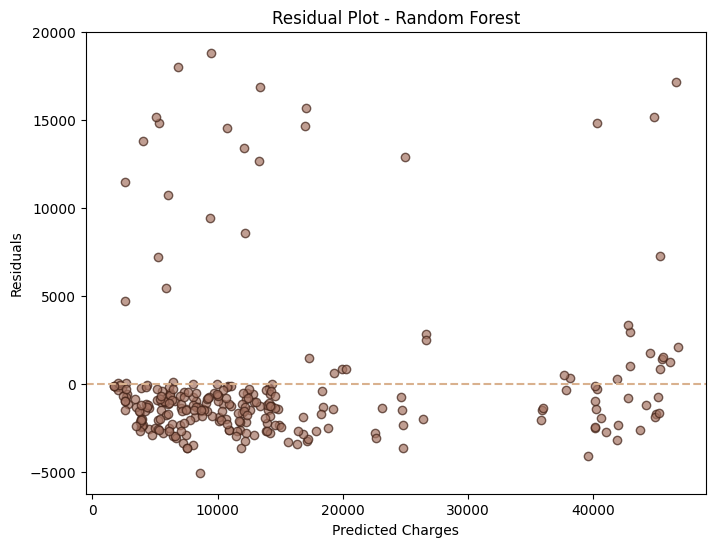

In [21]:
residuals = y_test - y_pred_random_forest

plt.figure(figsize=(8,6))

plt.scatter(y_pred_random_forest, residuals, color='#A67564', edgecolor=BROWN_EDGE, alpha=0.7)

plt.axhline(y=0, linestyle="--", color='#D9B18E')

plt.xlabel("Predicted Charges")
plt.ylabel("Residuals")
plt.title("Residual Plot - Random Forest")

plt.show()

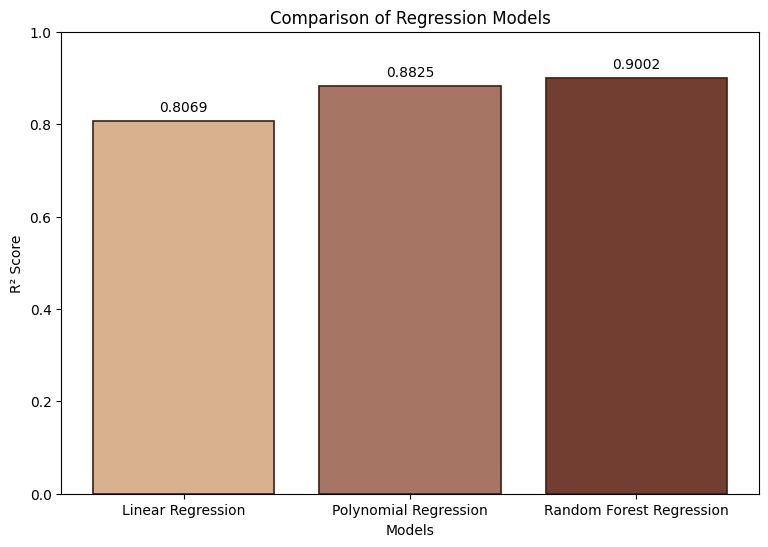

In [22]:
models = [
    "Linear Regression",
    "Polynomial Regression",
    "Random Forest Regression"
]

r2_scores = [
    r2_linear,
    r2_polynomial,
    r2_random_forest
]

plt.figure(figsize=(9,6))

bars = plt.bar(models, r2_scores, color=BROWN_PALETTE[:3], edgecolor=BROWN_EDGE, linewidth=1.2)

plt.xlabel("Models")
plt.ylabel("R² Score")
plt.title("Comparison of Regression Models")

plt.ylim(0, 1)

for bar, score in zip(bars, r2_scores):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        score + 0.02,
        f"{score:.4f}",
        ha="center"
    )

plt.show()

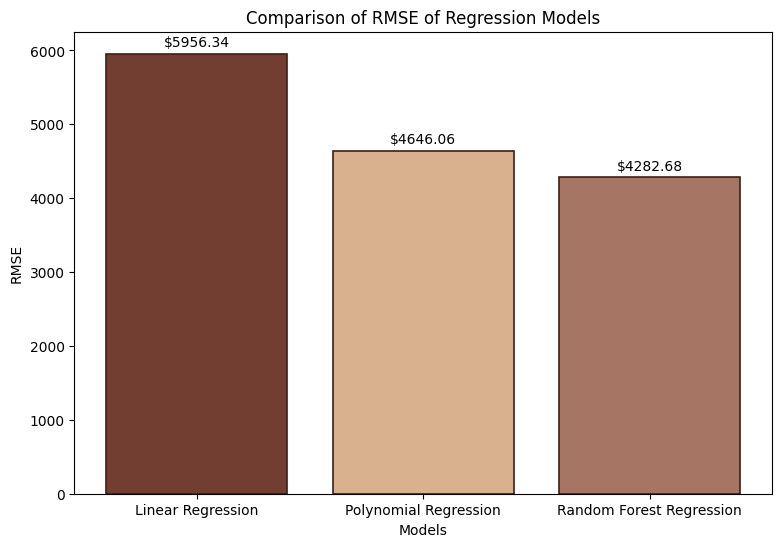

In [23]:
models = [
    "Linear Regression",
    "Polynomial Regression",
    "Random Forest Regression"
]

rmse_scores = [
    rmse_linear,
    rmse_polynomial,
    rmse_random_forest
]

plt.figure(figsize=(9,6))

bars = plt.bar(models, rmse_scores, color=[BROWN_PALETTE[2], BROWN_PALETTE[0], BROWN_PALETTE[1]], edgecolor=BROWN_EDGE, linewidth=1.2)

plt.xlabel("Models")
plt.ylabel("RMSE")
plt.title("Comparison of RMSE of Regression Models")

for bar, score in zip(bars, rmse_scores):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        score + 100,
        f"${score:.2f}",
        ha="center"
    )

plt.show()

## Final Conclusion

Three regression models were evaluated for predicting insurance charges: **Linear Regression, Polynomial Regression, and Random Forest Regression**.

The models were compared using **R² Score** and **RMSE**. The **Random Forest Regression** model achieved the best performance with an **R² Score of 0.9002 (90.02%)** and an **RMSE of $4,282.68**.

The final Random Forest model used the following parameters:

- **n_estimators:** 600
- **max_depth:** 15
- **min_samples_split:** 26
- **min_samples_leaf:** 12

Compared with Polynomial Regression, which achieved an **R² Score of 0.8825** and an **RMSE of $4,646.06**, Random Forest provided better predictions with a higher R² Score and lower RMSE.

Therefore, **Random Forest Regression was selected as the best-performing model** for predicting insurance charges. The model explains approximately **90.02% of the variation in the target variable**, indicating strong predictive performance.

In [24]:
import joblib
joblib.dump(random_forest_model, 'insurance_rf_model.pkl')
joblib.dump(X_train.columns.tolist(), 'model_columns.pkl')

['model_columns.pkl']

In [25]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
import joblib

# Page configuration
st.set_page_config(
    page_title="InsuranceAI Predictor",
    page_icon="💳",
    layout="centered"
)

# Custom Styling (Warm Brown Palette based on notebook theme)
st.markdown("""
    <style>
    .main {
        background-color: #FDFBF7;
    }
    .stButton>button {
        background-color: #3E1F14;
        color: #FFFFFF;
        font-weight: bold;
        border-radius: 8px;
        padding: 0.5rem 1rem;
        border: none;
        width: 100%;
    }
    .stButton>button:hover {
        background-color: #A67564;
        color: #FFFFFF;
    }
    .prediction-card {
        background-color: #D9B18E;
        padding: 20px;
        border-radius: 10px;
        border: 2px solid #3E1F14;
        text-align: center;
        color: #3E1F14;
        font-weight: bold;
    }
    </style>
""", unsafe_allow_html=True)

# Load the trained model and expected feature columns
@st.cache_resource
def load_assets():
    model = joblib.load('insurance_rf_model.pkl')
    columns = joblib.load('model_columns.pkl')
    return model, columns

try:
    model, model_columns = load_assets()
    model_loaded = True
except Exception as e:
    st.error(f"Error loading model files: {e}")
    model_loaded = False

# Application Title
st.title("💳 InsuranceAI Cost Predictor")
st.write("Enter the details below to estimate your medical insurance charges.")

st.divider()

# Input Form
with st.form("prediction_form"):
    col1, col2 = st.columns(2)
    
    with col1:
        age = st.number_input("Age", min_value=18, max_value=100, value=30, step=1)
        bmi = st.number_input("BMI (Body Mass Index)", min_value=10.0, max_value=60.0, value=25.0, step=0.1)
        sex = st.selectbox("Sex", ["male", "female"])
        
    with col2:
        children = st.number_input("Number of Children", min_value=0, max_value=10, value=0, step=1)
        smoker = st.selectbox("Smoker", ["no", "yes"])
        region = st.selectbox("Region", ["northeast", "northwest", "southeast", "southwest"])

    submit_button = st.form_submit_button("Calculate Estimated Charges")

# Prediction logic
if submit_button and model_loaded:
    input_data = {col: 0 for col in model_columns}
    
    input_data['age'] = age
    input_data['bmi'] = bmi
    input_data['children'] = children
    
    if 'sex' in input_data:
        input_data['sex'] = 1 if sex == 'male' else 0
    if 'smoker' in input_data:
        input_data['smoker'] = 1 if smoker == 'yes' else 0

    region_col = f"region_{region}"
    if region_col in input_data:
        input_data[region_col] = 1

    df_input = pd.DataFrame([input_data])
    prediction = model.predict(df_input)[0]
    
    st.divider()
    st.markdown(
        f"""
        <div class="prediction-card">
            <h3 style="margin: 0; color: #3E1F14;">Estimated Annual Insurance Charge</h3>
            <h1 style="margin: 10px 0; color: #3E1F14;">${prediction:,.2f}</h1>
        </div>
        """, 
        unsafe_allow_html=True
    )

Writing app.py


In [26]:
!pip install pyngrok streamlit -q

from pyngrok import ngrok
import subprocess

# Terminate existing tunnels if any
ngrok.kill()

# Start Streamlit process in the background
process = subprocess.Popen(["streamlit", "run", "app.py", "--server.port", "8501"])

# Open a public tunnel to port 8501
public_url = ngrok.connect(8501)
print(f"🔗 Click this link to open your Streamlit UI: {public_url}")

ERROR: Could not find a version that satisfies the requirement pyngrok (from versions: none)
ERROR: No matching distribution found for pyngrok


ModuleNotFoundError: No module named 'pyngrok'